# Model experimentation

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import numpy as np

sns.set_theme(style="whitegrid")


### Load data

In [2]:
df = pd.read_csv("../data/simulated/hourly_energy_data.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")

df.head()

,timestamp,electricity_price,temperature,production_load,historical_energy_usage
0,2026-01-01 00:00:00,0.915,-3.8,low,121.37
1,2026-01-01 01:00:00,0.977,-4.9,low,112.75
2,2026-01-01 02:00:00,0.917,-3.5,low,117.48
3,2026-01-01 03:00:00,0.937,-2.8,medium,150.58
4,2026-01-01 04:00:00,0.982,-1.2,medium,148.06


### Feature engineering

In [3]:
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.dayofweek
df["month"] = df["timestamp"].dt.month

df.head()

,timestamp,electricity_price,temperature,production_load,historical_energy_usage,hour,day_of_week,month
0,2026-01-01 00:00:00,0.915,-3.8,low,121.37,0,3,1
1,2026-01-01 01:00:00,0.977,-4.9,low,112.75,1,3,1
2,2026-01-01 02:00:00,0.917,-3.5,low,117.48,2,3,1
3,2026-01-01 03:00:00,0.937,-2.8,medium,150.58,3,3,1
4,2026-01-01 04:00:00,0.982,-1.2,medium,148.06,4,3,1


### Features and target

In [6]:
target = "historical_energy_usage"

features = [
    "electricity_price",
    "temperature",
    "production_load",
    "hour",
    "day_of_week",
    "month"
]

X = df[features]
y = df[target]

### Train/test split

In [7]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 1728
Test size: 432


### Preprocessing

In [8]:
numeric_features = [
    "electricity_price",
    "temperature",
    "hour",
    "day_of_week",
    "month"
]

categorical_features = [
    "production_load"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## Linear regression model

In [10]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

## Random forest model

In [11]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            max_depth=10
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

### MAE(Mean absolute error) and RMSE (Root mean square error)

In [12]:
def evalute_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mae, rmse

In [13]:
linear_mae, linear_rmse = evalute_model(y_test, linear_predictions)
rf_mae, rf_rmse = evalute_model(y_test, rf_predictions)

metrics_df = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse]
})

metrics_df

,model,MAE,RMSE
0,Linear Regression,7.925982,10.223226
1,Random Forest,5.297347,6.836916


### Visualize model comparisson

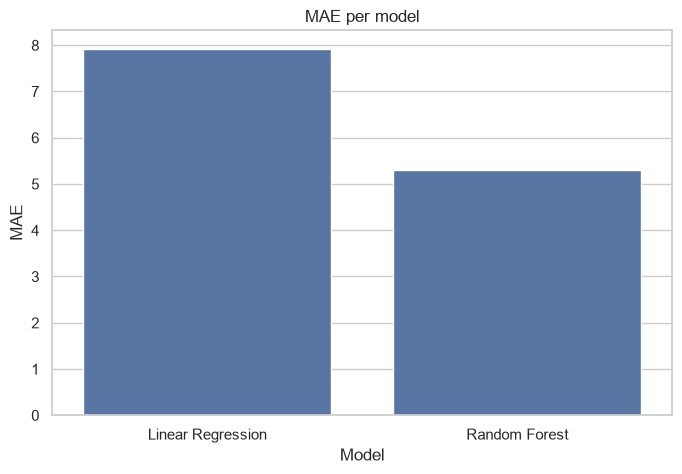

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=metrics_df,
    x="model",
    y="MAE"
)

plt.title("MAE per model")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.show()

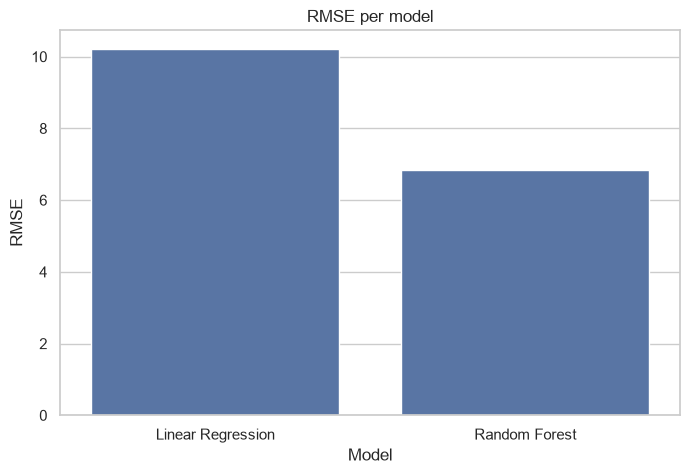

In [17]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=metrics_df,
    x="model",
    y="RMSE"
)

plt.title("RMSE per model")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.show()

### Actual vs predicted

In [19]:
results_df = pd.DataFrame({
    "timestamp": df["timestamp"].iloc[split_index:],
    "actual": y_test,
    "linear_regression": linear_predictions,
    "random_forest": rf_predictions
})

results_df.sample(10)

,timestamp,actual,linear_regression,random_forest
2003,2026-03-25 11:00:00,95.69,95.013951,95.580225
1879,2026-03-20 07:00:00,108.57,103.031955,110.907231
1731,2026-03-14 03:00:00,112.87,119.389432,117.215162
1811,2026-03-17 11:00:00,94.03,94.786322,91.343820
1913,2026-03-21 17:00:00,99.27,108.364961,104.305888
1958,2026-03-23 14:00:00,158.84,153.866300,157.591920
2038,2026-03-26 22:00:00,144.69,133.691111,131.541715
2049,2026-03-27 09:00:00,134.77,128.887466,132.815438
1994,2026-03-25 02:00:00,115.53,121.581933,119.452914
1991,2026-03-24 23:00:00,82.66,109.899125,88.865927


### Feature importance for Random Forest

In [21]:
trained_preprocessor = random_forest_model.named_steps["preprocessor"]
trained_rf = random_forest_model.named_steps["model"]

encoded_categorical_features = (
    trained_preprocessor
    .named_transformers_["cat"]
    .get_feature_names_out(categorical_features)
)

all_features_names = numeric_features + list(encoded_categorical_features)

feature_importance_df = pd.DataFrame({
    "feature": all_features_names,
    "importance": trained_rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_df

,feature,importance
5,production_load_high,0.423059
6,production_load_low,0.161447
2,hour,0.109313
7,production_load_medium,0.107262
1,temperature,0.105009
4,month,0.069162
0,electricity_price,0.018710
3,day_of_week,0.006038


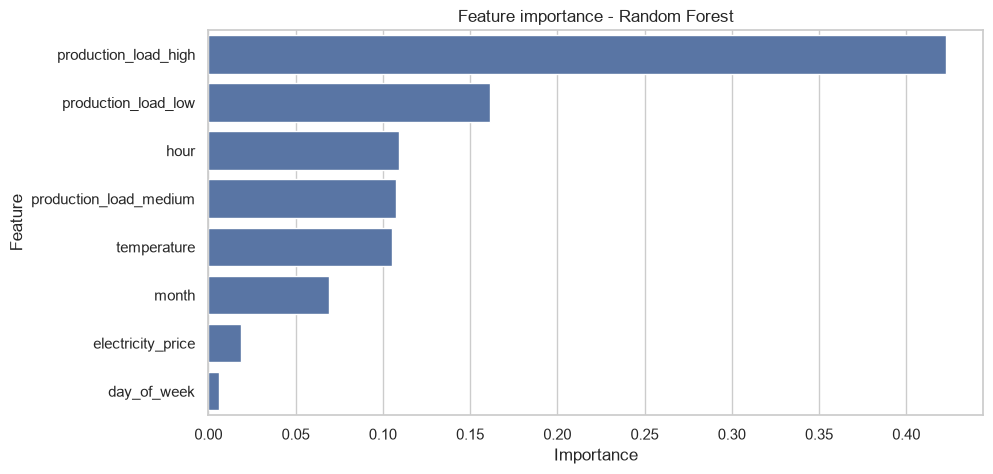

In [22]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature"
)

plt.title("Feature importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Conclussions:

- Linear regression is used as a simple baseline-model.
- Random Forest is used to catch more complex and non-linear connection. 
- MAE shows absolute mean errors. 
- RMSE punishes major erros more than MAE.
- Feature importance shows what variables Random Forest uses the most to explain the energy consumption. 

IMPORTANT: This notebook is only for experiment and storytelling. 
Production code is in 'src/'. 